# 🎯 sEMG Gesture Classification - NINAPRO DB1
## SOTA Models for Cross-Subject Generalization (Target: 80%+)

**Models:**
1. Multi-Stream TCN with Channel Attention
2. MSACNN-RM
3. **DANN (Domain-Adversarial)** - Best for cross-subject
4. SE-ResNet
5. Deep ConvLSTM

---

In [1]:
# Mount Drive & Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scipy tqdm

import numpy as np
import scipy.io
from scipy.signal import butter, filtfilt
import os, glob
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Configuration for Prosthetic Hand
class Config:
    DATASET_PATH = '/content/drive/MyDrive/NINAPRO'  # UPDATE THIS!
    SAMPLING_RATE = 100

    # Use all 10 channels
    NUM_CHANNELS = 10
    USE_CHANNELS = list(range(10))  # All 10 channels

    # Exclude:
    # Exercise B: 9-17  -> labels 21-29
    # Exercise C: 7,8   -> labels 36,37
    # Exercise C: 12-23 -> labels 41-52
    EXCLUDED_LABELS = EXCLUDED_LABELS = list(range(21, 30)) + [36, 37] + list(range(41, 53))

    WINDOW_SIZE = 50  # 500ms
    OVERLAP = 0.80
    LOWCUT, HIGHCUT = 20.0, 45.0
    BATCH_SIZE = 128
    EPOCHS = 100
    DROPOUT = 0.4
    SEED = 42

config = Config()
np.random.seed(config.SEED)
tf.random.set_seed(config.SEED)

print(f'Using {config.NUM_CHANNELS} EMG channels (all channels)')
print(f'Excluded labels: {config.EXCLUDED_LABELS} (none - all 52 gestures)')

Using 10 EMG channels (all channels)
Excluded labels: [21, 22, 23, 24, 25, 26, 27, 28, 29, 36, 37, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52] (none - all 52 gestures)


## Data Loading & Preprocessing

In [3]:
class NinaProLoader:
    def __init__(self, path, use_channels=list(range(8)), debug_files=False):
        self.path = path
        self.use_channels = use_channels
        self.debug_files = debug_files
        self.subjects = self._find_subjects()
        print(f'Found {len(self.subjects)} subjects')
        print(f'Using channels: {use_channels}')

    def _find_subjects(self):
        """
        Finds subjects from files like:
        S1_A1_E1.mat
        S10_A1_E2.mat
        S27_A1_E3.mat
        """
        files = glob.glob(os.path.join(self.path, '**', '*.mat'), recursive=True)

        subjects = set()
        for f in files:
            name = os.path.basename(f).upper()

            # Match only real NINAPRO DB1 filenames
            # Example: S1_A1_E1.mat, S27_A1_E3.mat
            match = re.match(r'^S(\d+)_A1_E[123]\.MAT$', name)
            if match:
                subjects.add(int(match.group(1)))

        return sorted(subjects)

    def _find_exact_file(self, subj_id, ex):
        """
        Finds the exact file for one subject and one exercise.
        This prevents Subject 1 from accidentally matching Subject 10/11/15/etc.
        """

        target_names = [
            f"S{subj_id}_A1_{ex}.mat",
            f"s{subj_id}_a1_{ex.lower()}.mat",
            f"S{subj_id:02d}_A1_{ex}.mat",
            f"s{subj_id:02d}_a1_{ex.lower()}.mat",
        ]

        for target in target_names:
            matches = glob.glob(
                os.path.join(self.path, '**', target),
                recursive=True
            )

            if matches:
                return sorted(matches)[0]

        return None

    def load_subject(self, subj_id):
        # E1: 12 movements -> labels 1-12
        # E2: 17 movements -> labels 13-29
        # E3: 23 movements -> labels 30-52
        offsets = {'E1': 0, 'E2': 12, 'E3': 29}

        emg_all, stim_all = [], []

        for ex in ['E1', 'E2', 'E3']:
            file_path = self._find_exact_file(subj_id, ex)

            if file_path is None:
                print(f"⚠️ Missing file for Subject {subj_id}, {ex}")
                continue

            if self.debug_files:
                print(f"Subject {subj_id}, {ex} -> {file_path}")

            mat = scipy.io.loadmat(file_path)

            emg = mat['emg'][:, self.use_channels]

            stim = mat['stimulus'].flatten().copy()
            stim[stim > 0] += offsets[ex]

            emg_all.append(emg)
            stim_all.append(stim)

        if not emg_all:
            return None

        return {
            'id': subj_id,
            'emg': np.vstack(emg_all),
            'stim': np.hstack(stim_all)
        }


class Preprocessor:
    def __init__(self, fs=100, lowcut=20, highcut=45, win_size=50, overlap=0.75,
                 excluded_labels=None):
        self.fs, self.lowcut, self.highcut = fs, lowcut, highcut
        self.win_size = win_size
        self.step = int(win_size * (1 - overlap))
        self.excluded_labels = excluded_labels or []

    def bandpass(self, emg):
        nyq = self.fs / 2
        b, a = butter(4, [self.lowcut / nyq, self.highcut / nyq], btype='band')
        return np.array([
            filtfilt(b, a, emg[:, ch])
            for ch in range(emg.shape[1])
        ]).T

    def process(self, data):
        emg = np.nan_to_num(data['emg'])
        emg = self.bandpass(emg)
        emg = StandardScaler().fit_transform(emg)

        labels = data['stim']

        n_win = (len(emg) - self.win_size) // self.step + 1

        windows, win_labels = [], []

        for i in range(n_win):
            s = i * self.step
            e = i * self.step + self.win_size

            vals, counts = np.unique(labels[s:e], return_counts=True)
            label = vals[np.argmax(counts)]

            # Skip rest and excluded labels
            if label == 0 or label in self.excluded_labels:
                continue

            windows.append(emg[s:e])
            win_labels.append(label)

        return np.array(windows), np.array(win_labels)

## Model Building Blocks

In [4]:
class SEBlock(Layer):
    def __init__(self, ratio=4, **kw):
        super().__init__(**kw)
        self.ratio = ratio
    def build(self, shape):
        ch = shape[-1]
        self.fc1 = Dense(max(ch // self.ratio, 1), activation='relu')
        self.fc2 = Dense(ch, activation='sigmoid')
    def call(self, x):
        squeeze = tf.reduce_mean(x, axis=1)
        excite = self.fc2(self.fc1(squeeze))
        return x * tf.expand_dims(excite, 1)

class TCNBlock(Layer):
    def __init__(self, filters, kernel, dilation, drop=0.2, **kw):
        super().__init__(**kw)
        self.filters, self.kernel, self.dilation, self.drop = filters, kernel, dilation, drop
    def build(self, shape):
        self.conv1 = Conv1D(self.filters, self.kernel, dilation_rate=self.dilation, padding='causal', activation='relu')
        self.bn1 = BatchNormalization()
        self.conv2 = Conv1D(self.filters, self.kernel, dilation_rate=self.dilation, padding='causal', activation='relu')
        self.bn2 = BatchNormalization()
        self.res = Conv1D(self.filters, 1) if shape[-1] != self.filters else None
        self.dropout = Dropout(self.drop)
    def call(self, x, training=None):
        out = self.dropout(self.bn1(self.conv1(x), training=training), training=training)
        out = self.dropout(self.bn2(self.conv2(out), training=training), training=training)
        res = self.res(x) if self.res else x
        return Activation('relu')(out + res)

In [5]:
# MODEL 1: Multi-Stream TCN
def build_multistream_tcn(input_shape, n_classes, drop=0.3):
    inp = Input(shape=input_shape)
    s1 = Conv1D(64, 3, padding='same', activation='relu')(inp)
    s1 = BatchNormalization()(s1)
    s1 = TCNBlock(64, 3, 1, drop)(s1)
    s1 = TCNBlock(64, 3, 2, drop)(s1)
    s1 = SEBlock()(s1)
    s2 = Conv1D(64, 5, padding='same', activation='relu')(inp)
    s2 = BatchNormalization()(s2)
    s2 = TCNBlock(64, 5, 2, drop)(s2)
    s2 = TCNBlock(64, 5, 4, drop)(s2)
    s2 = SEBlock()(s2)
    s3 = Conv1D(64, 7, padding='same', activation='relu')(inp)
    s3 = BatchNormalization()(s3)
    s3 = TCNBlock(64, 7, 4, drop)(s3)
    s3 = TCNBlock(64, 7, 8, drop)(s3)
    s3 = SEBlock()(s3)
    s4 = Bidirectional(LSTM(32, return_sequences=True))(inp)
    s4 = BatchNormalization()(s4)
    merged = Concatenate()([s1, s2, s3, s4])
    x = SEBlock()(merged)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(drop)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(drop)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='MultiStream_TCN')

# MODEL 2: MSACNN-RM
def build_msacnn_rm(input_shape, n_classes, drop=0.3):
    inp = Input(shape=input_shape)
    ch_w = Dense(input_shape[-1], activation='sigmoid')(GlobalAveragePooling1D()(inp))
    weighted = inp * Reshape((1, input_shape[-1]))(ch_w)
    def stream(x, k):
        s = Conv1D(64, k, padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
        s = BatchNormalization()(s)
        s = Conv1D(64, k, padding='same', kernel_regularizer=l2(0.001))(s)
        s = BatchNormalization()(s)
        r = Conv1D(64, 1, padding='same')(x)
        return Activation('relu')(Add()([s, r]))
    s1 = MaxPooling1D(2)(stream(weighted, 3))
    s2 = MaxPooling1D(2)(stream(weighted, 5))
    s3 = MaxPooling1D(2)(stream(weighted, 9))
    merged = Concatenate()([s1, s2, s3])
    x = Conv1D(256, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = BatchNormalization()(x)
    x = SEBlock()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(drop)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='MSACNN_RM')

# MODEL 4: SE-ResNet
def build_se_resnet(input_shape, n_classes, drop=0.3):
    inp = Input(shape=input_shape)
    x = Conv1D(64, 7, strides=2, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(3, strides=2, padding='same')(x)
    def se_block(x, f, stride=1):
        shortcut = x
        x = Conv1D(f, 3, strides=stride, padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = Conv1D(f, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = SEBlock()(x)
        if stride != 1 or shortcut.shape[-1] != f:
            shortcut = Conv1D(f, 1, strides=stride, padding='same')(shortcut)
            shortcut = BatchNormalization()(shortcut)
        return Activation('relu')(Add()([x, shortcut]))
    x = se_block(x, 64)
    x = se_block(x, 64)
    x = se_block(x, 128, stride=2)
    x = se_block(x, 128)
    x = se_block(x, 256, stride=2)
    x = se_block(x, 256)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(drop)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='SE_ResNet')

# MODEL 5: Deep ConvLSTM
def build_convlstm(input_shape, n_classes, drop=0.3):
    inp = Input(shape=input_shape)
    x = Conv1D(64, 5, padding='same', activation='relu', kernel_regularizer=l2(0.001))(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = SEBlock()(x)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=drop))(x)
    x = Bidirectional(LSTM(64, dropout=drop))(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(drop)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='ConvLSTM')

## 🔥 DANN Model with Custom Training (Gradient Reversal)

In [6]:
def build_dann_components_improved(input_shape, n_classes, n_subjects, drop=0.4):
    """
    Improved DANN with larger capacity for better accuracy.
    Changes:
    - More filters
    - Deeper network
    - Stronger regularization
    """
    # Shared Feature Extractor - IMPROVED
    inp = Input(shape=input_shape, name='input')

    # Stream 1 - Short-term patterns
    x1 = Conv1D(64, 3, padding='same', activation=None, kernel_regularizer=l2(0.001))(inp)
    x1 = BatchNormalization()(x1)
    x1 = Activation('relu')(x1)
    x1 = Conv1D(128, 3, padding='same', activation=None, kernel_regularizer=l2(0.001))(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation('relu')(x1)
    x1 = MaxPooling1D(2)(x1)

    # Stream 2 - Long-term patterns
    x2 = Conv1D(64, 7, padding='same', activation=None, kernel_regularizer=l2(0.001))(inp)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x2 = Conv1D(128, 7, padding='same', activation=None, kernel_regularizer=l2(0.001))(x2)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x2 = MaxPooling1D(2)(x2)

    # Stream 3 - Multi-scale
    x3 = Conv1D(64, 5, padding='same', activation=None, kernel_regularizer=l2(0.001))(inp)
    x3 = BatchNormalization()(x3)
    x3 = Activation('relu')(x3)
    x3 = Conv1D(128, 5, padding='same', activation=None, kernel_regularizer=l2(0.001))(x3)
    x3 = BatchNormalization()(x3)
    x3 = Activation('relu')(x3)
    x3 = MaxPooling1D(2)(x3)

    # Merge streams
    merged = Concatenate()([x1, x2, x3])

    # Additional processing
    x = Conv1D(512, 3, padding='same', activation=None, kernel_regularizer=l2(0.001))(merged)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(drop)(x)
    x = SEBlock()(x)

    x = Conv1D(256, 3, padding='same', activation=None, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SEBlock()(x)

    features = GlobalAveragePooling1D(name='features')(x)
    feature_extractor = Model(inp, features, name='feature_extractor')

    # Gesture Classifier - IMPROVED
    feat_inp = Input(shape=(256,), name='feat_input')
    g = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(feat_inp)
    g = Dropout(drop)(g)
    g = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(g)
    g = Dropout(drop)(g)
    g = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(g)
    g = Dropout(drop/2)(g)
    gesture_out = Dense(n_classes, activation='softmax', name='gesture')(g)
    gesture_classifier = Model(feat_inp, gesture_out, name='gesture_classifier')

    # Domain Discriminator
    d = Dense(256, activation='relu')(feat_inp)
    d = Dropout(0.4)(d)
    d = Dense(128, activation='relu')(d)
    d = Dropout(0.4)(d)
    domain_out = Dense(n_subjects, activation='softmax', name='domain')(d)
    domain_discriminator = Model(feat_inp, domain_out, name='domain_discriminator')

    return feature_extractor, gesture_classifier, domain_discriminator

In [7]:
from tqdm import tqdm

class DANNTrainer:
    def __init__(self, feature_extractor, gesture_classifier, domain_discriminator,
                 lambda_domain=1.0, lr=0.001):
        self.F = feature_extractor
        self.G = gesture_classifier
        self.D = domain_discriminator
        self.lambda_d = lambda_domain
        self.initial_lr = lr
        self.optimizer_F = keras.optimizers.Adam(lr)
        self.optimizer_G = keras.optimizers.Adam(lr)
        self.optimizer_D = keras.optimizers.Adam(lr)
        # Label smoothing for better generalization
        self.loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

    # OPTIMIZATION: Enable XLA compilation for massive speedup
    @tf.function(jit_compile=True)
    def train_step(self, x, y_gesture, y_domain, current_lambda):
        # OPTIMIZATION: Use persistent tape to compute features ONLY ONCE
        with tf.GradientTape(persistent=True) as tape:
            # 1. Forward pass (Single pass for F)
            features = self.F(x, training=True)
            gesture_pred = self.G(features, training=True)
            domain_pred = self.D(features, training=True)

            # 2. Compute losses
            loss_gesture = self.loss_fn(y_gesture, gesture_pred)
            loss_domain = self.loss_fn(y_domain, domain_pred)

            # DANN adversarial loss: Minimize gesture error, Maximize domain error
            total_loss = loss_gesture - current_lambda * loss_domain

        # 3. Calculate Gradients
        # Gradients for Domain Discriminator (minimize domain loss)
        grads_D = tape.gradient(loss_domain, self.D.trainable_variables)

        # Gradients for Feature Extractor & Classifier (minimize total loss)
        trainable_vars_fg = self.F.trainable_variables + self.G.trainable_variables
        grads_fg = tape.gradient(total_loss, trainable_vars_fg)

        del tape # Free resources explicitly

        # 4. Apply Updates
        self.optimizer_D.apply_gradients(zip(grads_D, self.D.trainable_variables))

        # Split gradients for F and G
        len_F = len(self.F.trainable_variables)
        grads_F = grads_fg[:len_F]
        grads_G = grads_fg[len_F:]

        self.optimizer_F.apply_gradients(zip(grads_F, self.F.trainable_variables))
        self.optimizer_G.apply_gradients(zip(grads_G, self.G.trainable_variables))

        # Metrics
        g_acc = tf.reduce_mean(tf.cast(tf.argmax(gesture_pred, 1) == tf.argmax(y_gesture, 1), tf.float32))
        d_acc = tf.reduce_mean(tf.cast(tf.argmax(domain_pred, 1) == tf.argmax(y_domain, 1), tf.float32))
        return loss_gesture, loss_domain, g_acc, d_acc

    def _get_lambda(self, epoch, total_epochs):
        """Progressive lambda: ramps from 0.2*lambda_d to lambda_d over training."""
        progress = min(epoch / (total_epochs * 0.5), 1.0)  # reaches full lambda at 50% of training
        return self.lambda_d * (0.2 + 0.8 * progress)

    def _adjust_lr(self, epoch, decay_every=25, decay_factor=0.5):
        """Decay learning rate every N epochs."""
        if epoch > 0 and epoch % decay_every == 0:
            new_lr = self.initial_lr * (decay_factor ** (epoch // decay_every))
            new_lr = max(new_lr, 1e-6)
            self.optimizer_F.learning_rate.assign(new_lr)
            self.optimizer_G.learning_rate.assign(new_lr)
            self.optimizer_D.learning_rate.assign(new_lr)
            print(f'  >> LR decayed to {new_lr:.6f}')

    def fit(self, X_train, y_gesture, y_domain, epochs=100, batch_size=64, X_val=None, y_val=None, patience=15, val_freq=1):
        # OPTIMIZATION: drop_remainder=True is required for effective XLA compilation
        dataset = tf.data.Dataset.from_tensor_slices((X_train, y_gesture, y_domain))
        dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

        # Total batches per epoch estimation (exact now due to drop_remainder)
        steps_per_epoch = len(X_train) // batch_size

        best_val_acc, patience_counter = 0, 0
        history = {'gesture_loss': [], 'gesture_acc': [], 'domain_acc': [], 'val_acc': []}

        # SPEED OPTIMIZATION: Create a combined model for fast validation using Keras's C++ loop
        val_model = None
        if X_val is not None:
            # Sequential wrapper that shares weights with self.F and self.G
            val_model = keras.Sequential([self.F, self.G])
            # Compile is needed for evaluate(), loss doesn't matter much for accuracy check but we include it
            val_model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

        try:
            for epoch in range(epochs):
                # Adjust learning rate
                self._adjust_lr(epoch)

                # Progressive lambda
                current_lambda = self._get_lambda(epoch, epochs)
                current_lambda_tf = tf.constant(current_lambda, dtype=tf.float32)

                g_losses, g_accs, d_accs = [], [], []

                # WRAP DATASET WITH TQDM
                pbar = tqdm(dataset, total=steps_per_epoch, desc=f'Epoch {epoch+1}/{epochs}', unit='batch')

                for x_batch, yg_batch, yd_batch in pbar:
                    gl, dl, ga, da = self.train_step(x_batch, yg_batch, yd_batch, current_lambda_tf)
                    g_losses.append(gl.numpy()); g_accs.append(ga.numpy()); d_accs.append(da.numpy())

                    # Update progress bar with current metrics
                    pbar.set_postfix({'g_loss': f'{gl.numpy():.3f}', 'g_acc': f'{ga.numpy():.3f}'})

                history['gesture_loss'].append(np.mean(g_losses))
                history['gesture_acc'].append(np.mean(g_accs))
                history['domain_acc'].append(np.mean(d_accs))

                val_str = ''
                # Check if we should validate this epoch
                if val_model is not None and (epoch + 1) % val_freq == 0:
                    # Use optimized evaluate (C++ loop) instead of manual Python loop
                    # verbose=0 to avoid cluttering output
                    _, val_acc = val_model.evaluate(X_val, y_val, batch_size=batch_size, verbose=0)

                    history['val_acc'].append(val_acc)
                    val_str = f' - val_acc: {val_acc:.4f}'

                    if val_acc > best_val_acc:
                        best_val_acc, patience_counter = val_acc, 0
                        self.best_F_weights = self.F.get_weights()
                        self.best_G_weights = self.G.get_weights()
                    else:
                        patience_counter += 1
                elif val_model is not None:
                     val_str = ' - val_acc: (skipped)'

                print(f'Done Epoch {epoch+1} - loss: {np.mean(g_losses):.4f} - g_acc: {np.mean(g_accs):.4f} - d_acc: {np.mean(d_accs):.4f} - λ: {current_lambda:.3f}{val_str}')

                if patience_counter >= patience:
                    print(f'Early stopping at epoch {epoch+1}')
                    self.F.set_weights(self.best_F_weights)
                    self.G.set_weights(self.best_G_weights)
                    break
        except KeyboardInterrupt:
            print('\nTraining interrupted by user. Returning history so far...')

        if X_val is not None:
          self.F.set_weights(self.best_F_weights)
          self.G.set_weights(self.best_G_weights)

        return history

    def predict(self, X):
        return self.G(self.F(X, training=False), training=False)

## Data Augmentation

In [8]:
def augment_enhanced(X, y, factor=3):
    """
    Enhanced data augmentation with more diverse transformations.

    Augmentations:
    - Gaussian noise injection
    - Amplitude scaling
    - Time shifting (circular shift)
    - Channel dropout (zero out random channels)
    """
    aug_X, aug_y = [X], [y]

    for _ in range(factor - 1):
        batch = []
        for sample in X:
            s = sample.copy()

            # Apply random augmentations
            augmentation_type = np.random.randint(0, 5)

            if augmentation_type == 0:
                # Gaussian noise
                s += np.random.normal(0, 0.02, s.shape)
            elif augmentation_type == 1:
                # Amplitude scaling
                s *= np.random.uniform(0.8, 1.2)
            elif augmentation_type == 2:
                # Time shift (circular)
                shift = np.random.randint(-5, 6)
                s = np.roll(s, shift, axis=0)
            elif augmentation_type == 3:
                # Channel dropout (zero out 1-2 random channels)
                n_drop = np.random.randint(1, 3)
                channels_to_drop = np.random.choice(s.shape[1], n_drop, replace=False)
                s[:, channels_to_drop] = 0
            else:
                # Combined: noise + scaling
                s += np.random.normal(0, 0.03, s.shape)
                s *= np.random.uniform(0.9, 1.1)

            batch.append(s)

        aug_X.append(np.array(batch))
        aug_y.append(y.copy())

    return np.vstack(aug_X), np.vstack(aug_y)


## Load Data

In [9]:
# Load with 8 channels only
loader = NinaProLoader(config.DATASET_PATH, use_channels=config.USE_CHANNELS)

# Preprocess with wrist movement exclusion
prep = Preprocessor(
    config.SAMPLING_RATE, config.LOWCUT, config.HIGHCUT,
    config.WINDOW_SIZE, config.OVERLAP,
    excluded_labels=config.EXCLUDED_LABELS  # Exclude B9-B17 (labels 21-29)
)

X_all, y_all, subj_all = [], [], []
for sid in tqdm(loader.subjects, desc='Loading'):
    data = loader.load_subject(sid)
    if data is None: continue
    windows, labels = prep.process(data)
    if len(windows) == 0: continue
    X_all.append(windows)
    y_all.append(labels)
    subj_all.append(np.full(len(labels), sid))

X = np.vstack(X_all).astype(np.float32)
y = np.hstack(y_all)
subjects = np.hstack(subj_all)

# Re-encode labels to be contiguous (0 to n_classes-1)
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(le.classes_)

print(f'\n=== Data Summary ===')
print(f'Total samples: {len(X):,}')
print(f'Input shape: {X.shape[1:]} (window_size, {config.NUM_CHANNELS} channels)')
print(f'Number of classes: {n_classes} (after excluding wrist movements)')
print(f'Subjects: {len(np.unique(subjects))}')
print(f'Original labels used: {sorted(le.classes_)}')
print(f'Excluded labels (wrist B9-B17): {config.EXCLUDED_LABELS}')

Found 27 subjects
Using channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Loading: 100%|██████████| 27/27 [01:51<00:00,  4.11s/it]



=== Data Summary ===
Total samples: 448,827
Input shape: (50, 10) (window_size, 10 channels)
Number of classes: 29 (after excluding wrist movements)
Subjects: 27
Original labels used: [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(38), np.uint8(39), np.uint8(40)]
Excluded labels (wrist B9-B17): [21, 22, 23, 24, 25, 26, 27, 28, 29, 36, 37, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]


## Prepare Train/Test Split

In [10]:
# Seen-data training/evaluation split
# Train on ALL subjects, evaluate on ALL subjects
# This is for checking how well the model learns data it has already seen.

train_subj = np.unique(subjects)
test_subj = np.unique(subjects)   # only for reporting; not a held-out test anymore

X_train = X
y_train = y_enc
subj_train = subjects

# One-hot labels
y_train_oh = to_categorical(y_train, n_classes).astype(np.float32)

# Encode ALL subject IDs for DANN domain labels
subj_le = LabelEncoder()
subj_train_enc = subj_le.fit_transform(subj_train)
n_train_subjects = len(subj_le.classes_)
subj_train_oh = to_categorical(subj_train_enc, n_train_subjects).astype(np.float32)

# Augment all training data
X_train_aug, y_train_aug = augment_enhanced(X_train, y_train_oh, factor=2)
subj_train_aug = np.vstack([subj_train_oh, subj_train_oh]).astype(np.float32)

# Validation split from the same seen-data pool
val_size = int(0.1 * len(X_train_aug))
indices = np.random.permutation(len(X_train_aug))

X_val = X_train_aug[indices[:val_size]]
y_val = y_train_aug[indices[:val_size]]

X_tr = X_train_aug[indices[val_size:]]
y_tr = y_train_aug[indices[val_size:]]
subj_tr = subj_train_aug[indices[val_size:]]

print(f'Train: {len(X_tr):,}  Val: {len(X_val):,}')
print(f'Seen-data evaluation set will be the full original dataset: {len(X):,}')
print(f'Subjects used in training: {list(train_subj)}')

Train: 807,889  Val: 89,765
Seen-data evaluation set will be the full original dataset: 448,827
Subjects used in training: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]


## Select and Train Model

In [11]:
# Choose: 'multistream_tcn', 'msacnn_rm', 'dann', 'se_resnet', 'convlstm'
MODEL_CHOICE = 'dann'

if MODEL_CHOICE == 'dann':
    print('Building DANN for cross-subject generalization...')
    F, G, D = build_dann_components_improved(X_train.shape[1:], n_classes, n_train_subjects)
    trainer = DANNTrainer(F, G, D, lambda_domain=0.5, lr=0.001)
    print(f'Feature Extractor: {F.count_params():,} params')
    print(f'Gesture Classifier: {G.count_params():,} params')
else:
    models = {'multistream_tcn': build_multistream_tcn, 'msacnn_rm': build_msacnn_rm,
              'se_resnet': build_se_resnet, 'convlstm': build_convlstm}
    model = models[MODEL_CHOICE](X_train.shape[1:], n_classes)
    model.summary()

Building DANN for cross-subject generalization...
Feature Extractor: 1,287,040 params
Gesture Classifier: 299,549 params


In [12]:
# Train
import gc
import numpy as np
import tensorflow as tf

# Clear GPU memory
tf.keras.backend.clear_session()
gc.collect()


if MODEL_CHOICE == 'dann':
    print('\n🚀 Training DANN...\n')
    # Using config.BATCH_SIZE
    history = trainer.fit(X_tr, y_tr, subj_tr, epochs=200, batch_size=config.BATCH_SIZE,
                         X_val=X_val, y_val=y_val, patience=15)
else:
    callbacks = [EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
                 ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1)]
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=config.EPOCHS,
                       batch_size=config.BATCH_SIZE, callbacks=callbacks)


🚀 Training DANN...



Epoch 1/200: 100%|██████████| 6311/6311 [01:14<00:00, 84.55batch/s, g_loss=2.542, g_acc=0.312] 


Done Epoch 1 - loss: 2.8281 - g_acc: 0.2090 - d_acc: 0.1195 - λ: 0.100 - val_acc: 0.2881


Epoch 2/200: 100%|██████████| 6311/6311 [00:31<00:00, 198.33batch/s, g_loss=2.161, g_acc=0.484]


Done Epoch 2 - loss: 2.4473 - g_acc: 0.3485 - d_acc: 0.1603 - λ: 0.104 - val_acc: 0.3884


...

Done Epoch 198 - loss: 1.0408 - g_acc: 0.8713 - d_acc: 0.0747 - λ: 0.500 - val_acc: 0.8910


Epoch 199/200: 100%|██████████| 6311/6311 [00:32<00:00, 192.64batch/s, g_loss=0.945, g_acc=0.922]


Done Epoch 199 - loss: 1.0418 - g_acc: 0.8708 - d_acc: 0.0746 - λ: 0.500 - val_acc: 0.8908


Epoch 200/200: 100%|██████████| 6311/6311 [00:32<00:00, 194.93batch/s, g_loss=1.165, g_acc=0.852]


Done Epoch 200 - loss: 1.0409 - g_acc: 0.8707 - d_acc: 0.0738 - λ: 0.500 - val_acc: 0.8911


In [14]:
# Evaluate on ALL seen data
X_seen = X
y_seen = y_enc
y_seen_oh = to_categorical(y_seen, n_classes).astype(np.float32)

if MODEL_CHOICE == 'dann':
    batch_size = 512
    preds_list = []
    for i in range(0, len(X_seen), batch_size):
        batch_preds = trainer.predict(X_seen[i:i+batch_size]).numpy()
        preds_list.append(batch_preds)
    preds = np.vstack(preds_list)
else:
    preds = model.predict(X_seen, verbose=0)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_seen_oh, axis=1)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred)

print('\n' + '='*60)
print(f'🦾 PROSTHETIC HAND MODEL: {MODEL_CHOICE}')
print(f'Channels: {config.NUM_CHANNELS} (forearm only)')
print(f'Classes: {n_classes} (wrist movements excluded)')
print(f'Evaluation: ALL SEEN DATA')
print(f'Subjects included: {list(np.unique(subjects))}')
print(f'Seen-Data Accuracy: {acc*100:.2f}%')
print(f'F1 Score: {f1:.4f}')
print('='*60)


🦾 PROSTHETIC HAND MODEL: dann
Channels: 10 (forearm only)
Classes: 29 (wrist movements excluded)
Evaluation: ALL SEEN DATA
Subjects included: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]
Seen-Data Accuracy: 96.19%
F1 Score: 0.9622


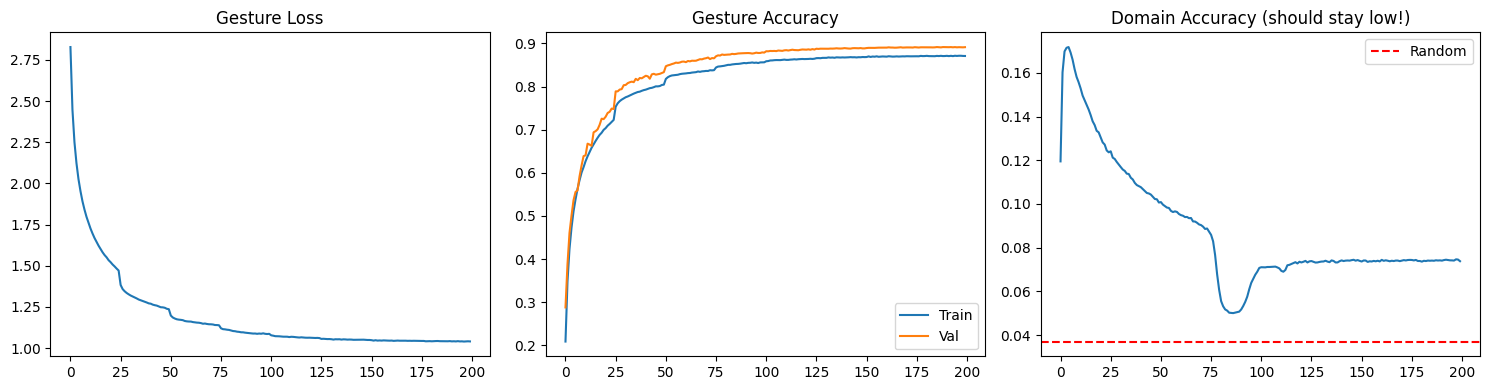

In [15]:
# Plot training history
if MODEL_CHOICE == 'dann':
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['gesture_loss'])
    axes[0].set_title('Gesture Loss')
    axes[1].plot(history['gesture_acc'], label='Train')
    if history['val_acc']:
        axes[1].plot(history['val_acc'], label='Val')
    axes[1].legend()
    axes[1].set_title('Gesture Accuracy')
    axes[2].plot(history['domain_acc'])
    axes[2].axhline(y=1/n_train_subjects, color='r', linestyle='--', label='Random')
    axes[2].legend()
    axes[2].set_title('Domain Accuracy (should stay low!)')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.legend()
    plt.title('Loss')
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    plt.show()

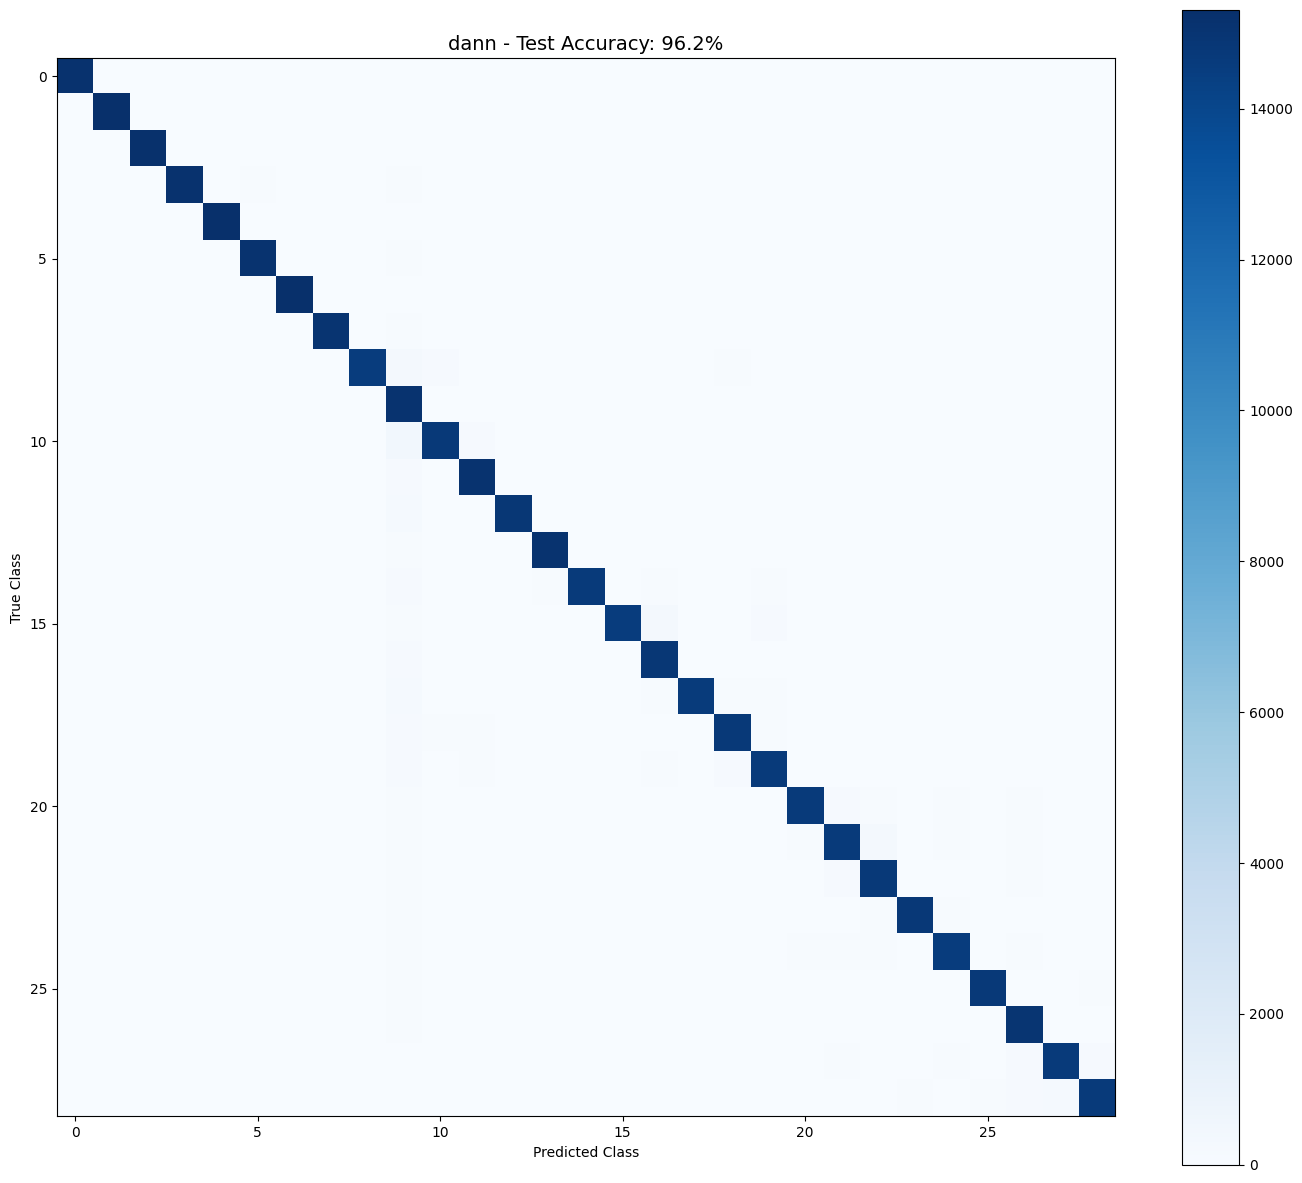

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.title(f'{MODEL_CHOICE} - Test Accuracy: {acc*100:.1f}%', fontsize=14)
plt.colorbar()
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

In [17]:
# Save DANN model components
save_path = '/content/drive/MyDrive/models_grad_project/'  # Change to your path
import os
os.makedirs(save_path, exist_ok=True)

# Save each component
trainer.F.save(save_path + 'dann_feature_extractor_all_new_29.keras')
trainer.G.save(save_path + 'dann_gesture_classifier_all_new_29.keras')
trainer.D.save(save_path + 'dann_domain_discriminator_all_new_29.keras')

print(f'Models saved to {save_path}')

Models saved to /content/drive/MyDrive/models_grad_project/


In [20]:
# Load DANN model

from tensorflow import keras
import numpy as np

# Define the path where models were saved
model_save_path = '/content/drive/MyDrive/models_grad_project/'

# Load components
F = keras.models.load_model(model_save_path + 'dann_feature_extractor_all_new_29.keras',
                            custom_objects={'SEBlock': SEBlock})
G = keras.models.load_model(model_save_path + 'dann_gesture_classifier_all_new_29.keras')
D = keras.models.load_model(model_save_path + 'dann_domain_discriminator_all_new_29.keras')

# Recreate trainer (optional - only if you want to continue training)
# trainer = DANNTrainer(F, G, D, lambda_domain=0.5, lr=0.001)

# Or just use for inference with batching to avoid OOM:
def predict(X, batch_size=512):
    preds = []
    for i in range(0, len(X), batch_size):
        features = F(X[i:i+batch_size], training=False)
        batch_preds = G(features, training=False)
        preds.append(batch_preds.numpy())
    return np.vstack(preds)

# Example using validation data
preds = predict(X_val)


In [21]:
# Save DANN Results
import json
import pickle

save_path = '/content/drive/MyDrive/Graduation Project/ninapro_results'  # Change to your path
os.makedirs(save_path, exist_ok=True)

# 1. Save metrics
results = {
    'model': 'DANN',
    'test_subjects': [int(x) for x in test_subj],
    'accuracy': float(acc),
    'f1_score': float(f1),
    'n_classes': int(n_classes),
    'n_train_subjects': int(n_train_subjects),
    'epochs_trained': len(history['gesture_loss'])
}

with open(save_path + 'dann_results_all_new_29.json', 'w') as f:
    json.dump(results, f, indent=2)

# 2. Save predictions
np.save(save_path + 'dann_predictions_all_new_29.npy', preds)
np.save(save_path + 'dann_true_labels_all_new_29.npy', y_true)

# 3. Save confusion matrix
np.save(save_path + 'dann_confusion_matrix_all_new_29.npy', cm)

# 4. Save training history
with open(save_path + 'dann_history_all_new_29.pkl', 'wb') as f:
    pickle.dump(history, f)

# 5. Save confusion matrix as image
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.title(f'DANN - Accuracy: {acc*100:.1f}%')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(save_path + 'dann_confusion_matrix_all_new_29.png', dpi=150, bbox_inches='tight')
plt.close()

print(f'✅ Results saved to {save_path}')
print(f'   - dann_results_all_new.json (metrics)')
print(f'   - dann_predictions_all_new.npy')
print(f'   - dann_confusion_matrix_all_new.npy/.png')
print(f'   - dann_history_all_new.pkl')

✅ Results saved to /content/drive/MyDrive/Graduation Project/ninapro_results
   - dann_results_all_new.json (metrics)
   - dann_predictions_all_new.npy
   - dann_confusion_matrix_all_new.npy/.png
   - dann_history_all_new.pkl


In [ ]:


"""
# Load
with open(model_save_path + 'dann_results.json', 'r') as f:
    results = json.load(f)
print(f"Accuracy: {results['accuracy']*100:.2f}%")

preds = np.load(save_path + 'dann_predictions.npy')
cm = np.load(save_path + 'dann_confusion_matrix.npy')
"""



### Save Subject-Specific Scalers for Real-Time Use

In [ ]:
import pickle
import os
from sklearn.preprocessing import StandardScaler

# We will use the existing loader and preprocessor logic to ensure consistency
loader = NinaProLoader(config.DATASET_PATH, use_channels=config.USE_CHANNELS)
prep = Preprocessor(config.SAMPLING_RATE, config.LOWCUT, config.HIGHCUT)

def get_subject_scaler(subject_id):
    print(f"Loading data for Subject {subject_id}...")
    data = loader.load_subject(subject_id)
    if data is None:
        print(f"Data for Subject {subject_id} not found.")
        return None

    # 1. Get raw EMG
    emg = np.nan_to_num(data['emg'])

    # 2. Bandpass filter FIRST (this matches your Preprocessor logic)
    emg_filtered = prep.bandpass(emg)

    # 3. Fit the scaler on the ENTIRE session data
    scaler = StandardScaler()
    scaler.fit(emg_filtered)

    return scaler

# Fit scalers for Subject 26 and 27
scaler_26 = get_subject_scaler(26)
scaler_27 = get_subject_scaler(27)

# Save to Drive
save_path = '/content/drive/MyDrive/models_grad_project/'
os.makedirs(save_path, exist_ok=True)

if scaler_26:
    with open(save_path + 'scaler_subject_26_29.pkl', 'wb') as f:
        pickle.dump(scaler_26, f)
    print("\n✅ Saved Scaler for Subject 26 -> scaler_subject_26_29.pkl")

if scaler_27:
    with open(save_path + 'scaler_subject_27_29.pkl', 'wb') as f:
        pickle.dump(scaler_27, f)
    print("✅ Saved Scaler for Subject 27 -> scaler_subject_27_29.pkl")


### Evaluate Model on Each Subject Individually

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
import gc

print("Evaluating model on each subject individually...\n")
subject_accuracies = {}

# Clear session to free up GPU memory
tf.keras.backend.clear_session()
gc.collect()

# Loop through all unique subjects in the dataset
for subj_id in np.unique(subjects):
    # Extract data for the current subject
    mask = (subjects == subj_id)
    X_subj = X[mask]
    y_subj_true = y_enc[mask]

    # Use Keras built-in predict which handles memory much better
    if MODEL_CHOICE == 'dann':
        features = trainer.F.predict(X_subj, batch_size=512, verbose=0)
        preds = trainer.G.predict(features, batch_size=512, verbose=0)
    else:
        preds = model.predict(X_subj, batch_size=512, verbose=0)

    y_subj_pred = np.argmax(preds, axis=1)

    # Calculate and store accuracy
    acc = accuracy_score(y_subj_true, y_subj_pred)
    subject_accuracies[subj_id] = acc

    print(f"Subject {subj_id:02d} Accuracy: {acc*100:.2f}%")

# Print summary statistics
print("\n" + "="*40)
print("--- Summary ---")
best_subj = max(subject_accuracies, key=subject_accuracies.get)
worst_subj = min(subject_accuracies, key=subject_accuracies.get)
print(f"Best Subject:  {best_subj} ({subject_accuracies[best_subj]*100:.2f}%)")
print(f"Worst Subject: {worst_subj} ({subject_accuracies[worst_subj]*100:.2f}%)")
print(f"Average Acc:   {np.mean(list(subject_accuracies.values()))*100:.2f}%")
print("="*40)


Evaluating model on each subject individually...

Subject 01 Accuracy: 90.76%
Subject 02 Accuracy: 94.58%
Subject 03 Accuracy: 93.26%
Subject 04 Accuracy: 97.43%
Subject 05 Accuracy: 98.27%
Subject 06 Accuracy: 96.60%
Subject 07 Accuracy: 98.07%
Subject 08 Accuracy: 96.42%
Subject 09 Accuracy: 98.21%
Subject 10 Accuracy: 97.26%
Subject 11 Accuracy: 98.12%
Subject 12 Accuracy: 96.49%
Subject 13 Accuracy: 96.20%
Subject 14 Accuracy: 96.73%
Subject 15 Accuracy: 97.23%
Subject 16 Accuracy: 93.48%
Subject 17 Accuracy: 91.04%
Subject 18 Accuracy: 92.65%
Subject 19 Accuracy: 94.42%
Subject 20 Accuracy: 96.62%
Subject 21 Accuracy: 96.20%
Subject 22 Accuracy: 99.02%
Subject 23 Accuracy: 96.73%
Subject 24 Accuracy: 96.09%
Subject 25 Accuracy: 98.78%
Subject 26 Accuracy: 97.03%
Subject 27 Accuracy: 99.39%

--- Summary ---
Best Subject:  27 (99.39%)
Worst Subject: 1 (90.76%)
Average Acc:   96.19%


In [ ]:
import pickle
import os

# Use your existing function to get the scaler for Subject 1
scaler_1 = get_subject_scaler(1)

if scaler_1:
    save_path = '/content/drive/MyDrive/models_grad_project/'
    os.makedirs(save_path, exist_ok=True)

    file_path = os.path.join(save_path, 'scaler_subject_01_29.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(scaler_1, f)
    print(f"\n✅ Saved Scaler for Subject 1 -> {file_path}")


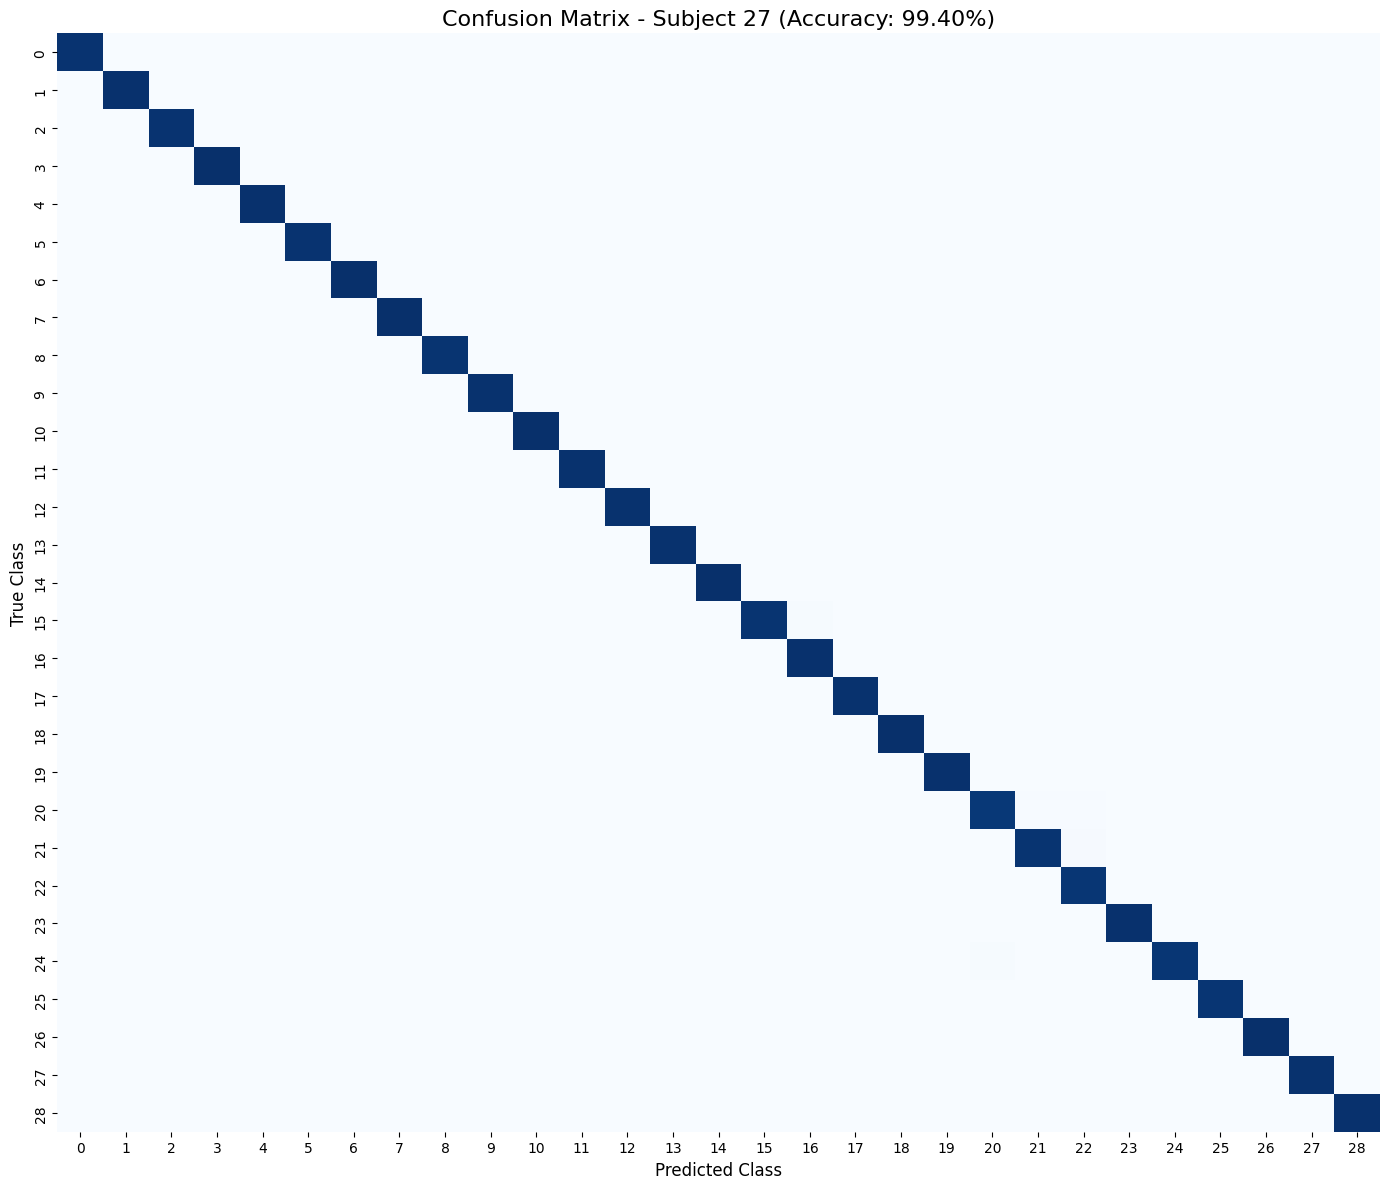

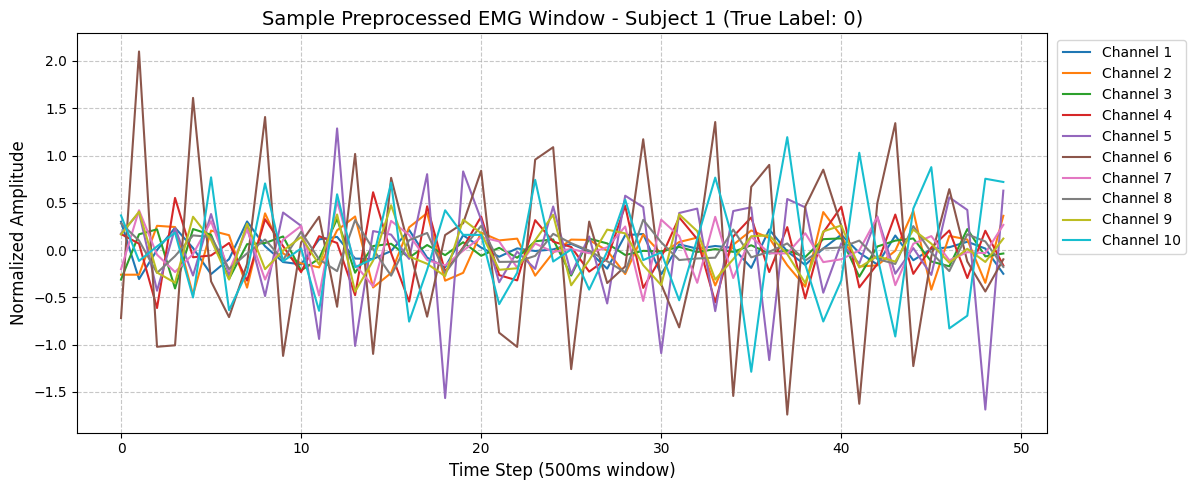

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Extract Subject 1 data
mask_27 = (subjects == 27)
X_subj27 = X[mask_27]
y_true_subj27 = y_enc[mask_27]

# 2. Get predictions for Subject 1
if MODEL_CHOICE == 'dann':
    preds_subj27 = trainer.predict(X_subj27).numpy()
else:
    preds_subj27 = model.predict(X_subj27, verbose=0)

y_pred_subj27 = np.argmax(preds_subj27, axis=1)
acc_subj27 = accuracy_score(y_true_subj27, y_pred_subj27)

# 3. Plot Confusion Matrix
cm_subj27 = confusion_matrix(y_true_subj27, y_pred_subj27)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_subj27, cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - Subject 27 (Accuracy: {acc_subj27*100:.2f}%)', fontsize=16)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Plot a Sample Preprocessed EMG Signal from Subject 27
plt.figure(figsize=(12, 5))
sample_idx = 0  # First window
plt.plot(X_subj27[sample_idx])
plt.title(f'Sample Preprocessed EMG Window - Subject 1 (True Label: {y_true_subj27[sample_idx]})', fontsize=14)
plt.xlabel('Time Step (500ms window)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.legend([f'Channel {i+1}' for i in range(X_subj27.shape[2])], loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [36]:
import numpy as np
import os

save_path = '/content/drive/MyDrive/models_grad_project/'
os.makedirs(save_path, exist_ok=True)

np.save(save_path + 'label_classes_new_29.npy', le.classes_)

print("✅ Saved label_classes.npy")

✅ Saved label_classes.npy


In [34]:
config_info = {
    "sampling_rate": config.SAMPLING_RATE,
    "num_channels": config.NUM_CHANNELS,
    "use_channels": config.USE_CHANNELS,
    "window_size": config.WINDOW_SIZE,
    "overlap": config.OVERLAP,
    "lowcut": config.LOWCUT,
    "highcut": config.HIGHCUT,
    "excluded_labels": config.EXCLUDED_LABELS,
    "input_shape": list(X.shape[1:]),
    "n_classes": int(n_classes)
}

In [35]:
import json
import os

save_path = '/content/drive/MyDrive/models_grad_project/'
os.makedirs(save_path, exist_ok=True)

with open(save_path + 'preprocessing_config_new_29.json', 'w') as f:
    json.dump(config_info, f, indent=2)

print("✅ Saved preprocessing_config.json")

✅ Saved preprocessing_config.json


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Extract Subject 17 data
mask_17 = (subjects == 17)
X_subj17 = X[mask_17]
y_true_subj17 = y_enc[mask_17]

# 2. Get predictions for Subject 17
if MODEL_CHOICE == 'dann':
    preds_subj17 = trainer.predict(X_subj17).numpy()
else:
    preds_subj17 = model.predict(X_subj17, verbose=0)

y_pred_subj17 = np.argmax(preds_subj17, axis=1)
acc_subj17 = accuracy_score(y_true_subj17, y_pred_subj17)

# 3. Plot Confusion Matrix
cm_subj17 = confusion_matrix(y_true_subj17, y_pred_subj17)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_subj17, cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - Subject 17 (Accuracy: {acc_subj17*100:.2f}%)', fontsize=16)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Plot a Sample Preprocessed EMG Signal from Subject 17
plt.figure(figsize=(12, 5))
sample_idx = 0  # First window
plt.plot(X_subj17[sample_idx])
plt.title(f'Sample Preprocessed EMG Window - Subject 17 (True Label: {y_true_subj17[sample_idx]})', fontsize=14)
plt.xlabel('Time Step (500ms window)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.legend([f'Channel {i+1}' for i in range(X_subj17.shape[2])], loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Extract Subject 22 data
mask_22 = (subjects == 22)
X_subj22 = X[mask_22]
y_true_subj22 = y_enc[mask_22]

# 2. Get predictions for Subject 22
if MODEL_CHOICE == 'dann':
    preds_subj22 = trainer.predict(X_subj22).numpy()
else:
    preds_subj22 = model.predict(X_subj22, verbose=0)

y_pred_subj22 = np.argmax(preds_subj22, axis=1)
acc_subj22 = accuracy_score(y_true_subj22, y_pred_subj22)

# 3. Plot Confusion Matrix
cm_subj22 = confusion_matrix(y_true_subj22, y_pred_subj22)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_subj22, cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - Subject 22 (Accuracy: {acc_subj22*100:.2f}%)', fontsize=16)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Plot a Sample Preprocessed EMG Signal from Subject 22
plt.figure(figsize=(12, 5))
sample_idx = 0  # First window
plt.plot(X_subj22[sample_idx])
plt.title(f'Sample Preprocessed EMG Window - Subject 22 (True Label: {y_true_subj22[sample_idx]})', fontsize=14)
plt.xlabel('Time Step (500ms window)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.legend([f'Channel {i+1}' for i in range(X_subj22.shape[2])], loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()